# Didos problem 

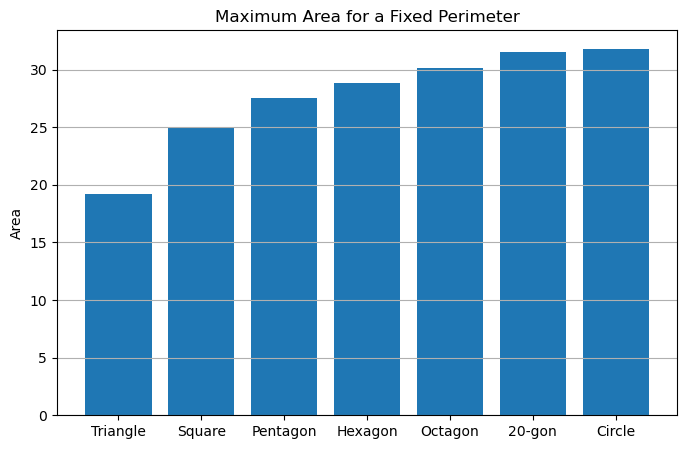

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Fixed perimeter
# ----------------------------------------

P = 20

polygons = {
    "Triangle":3,
    "Square":4,
    "Pentagon":5,
    "Hexagon":6,
    "Octagon":8,
    "20-gon":20
}

areas=[]
labels=[]

for name,n in polygons.items():

    s=P/n

    area=(n*s*s)/(4*np.tan(np.pi/n))

    areas.append(area)
    labels.append(name)

# Circle
circle_area=P**2/(4*np.pi)

areas.append(circle_area)
labels.append("Circle")

plt.figure(figsize=(8,5))

plt.bar(labels,areas)

plt.ylabel("Area")
plt.title("Maximum Area for a Fixed Perimeter")

plt.grid(axis='y')

plt.show()

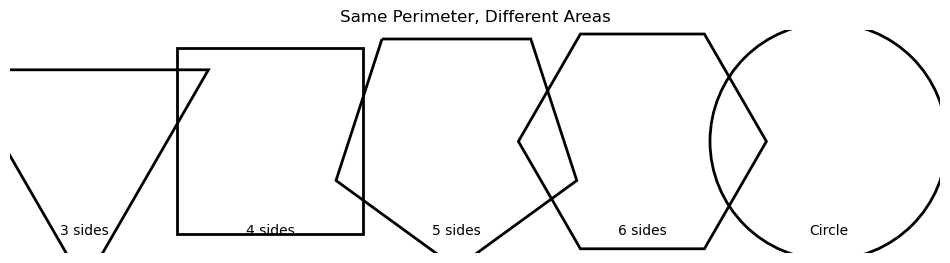

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon, Circle

P=20

fig,ax=plt.subplots(figsize=(12,3))

shapes=[3,4,5,6]

x=0

for n in shapes:

    s=P/n

    R=s/(2*np.sin(np.pi/n))

    poly=RegularPolygon(
        (x,0),
        numVertices=n,
        radius=R,
        orientation=np.pi/n,
        fill=False,
        linewidth=2
    )

    ax.add_patch(poly)

    ax.text(x,-2.5,f"{n} sides",ha='center')

    x+=5

# Circle
r=P/(2*np.pi)

circle=Circle((x,0),r,fill=False,linewidth=2)

ax.add_patch(circle)

ax.text(x,-2.5,"Circle",ha='center')

ax.set_xlim(-2,x+3)
ax.set_ylim(-3,3)
ax.set_aspect('equal')
ax.axis('off')

plt.title("Same Perimeter, Different Areas")

plt.show()

# Honey comb problem 

Triangle    side = 1.5197   perimeter = 4.5590
Square      side = 1.0000   perimeter = 4.0000
Hexagon     side = 0.6204   perimeter = 3.7224


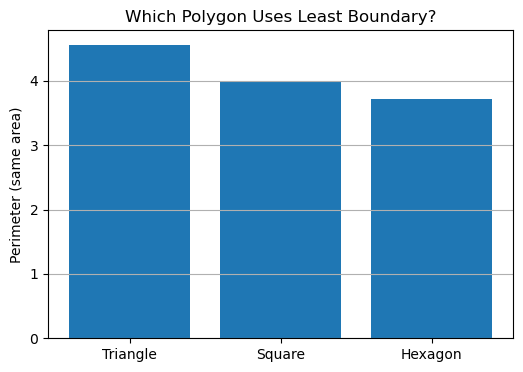

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# Compare perimeter for equal-area polygons
# ---------------------------------------------

A = 1.0                      # Fixed area

polygons = {
    "Triangle": 3,
    "Square": 4,
    "Hexagon": 6
}

perimeters = []

for name, n in polygons.items():

    # Area of a regular n-gon:
    # A = n*s^2 / (4*tan(pi/n))
    s = np.sqrt(4*A*np.tan(np.pi/n)/n)

    perimeter = n*s
    perimeters.append(perimeter)

    print(f"{name:10s}  side = {s:.4f}   perimeter = {perimeter:.4f}")

# Plot
plt.figure(figsize=(6,4))
plt.bar(polygons.keys(), perimeters)

plt.ylabel("Perimeter (same area)")
plt.title("Which Polygon Uses Least Boundary?")
plt.grid(axis='y')

plt.show()

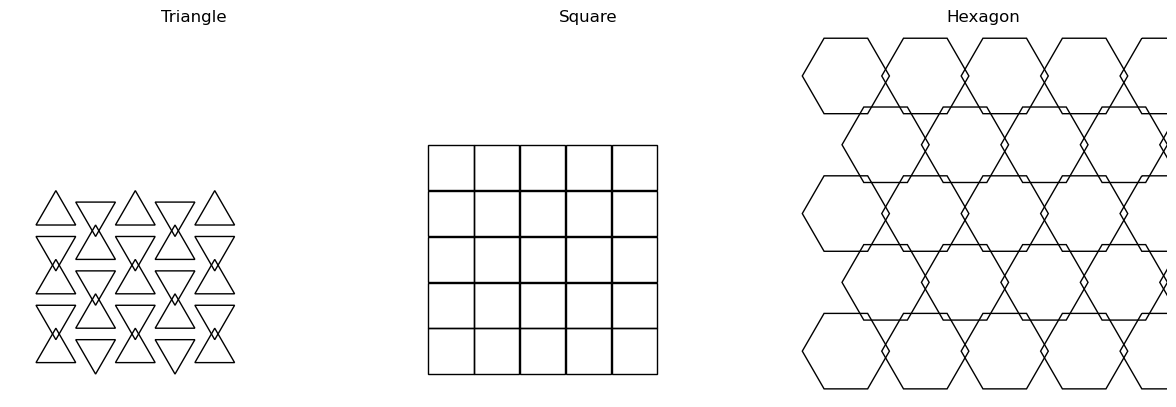

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

fig, ax = plt.subplots(1,3,figsize=(12,4))

shapes = [
    ("Triangle",3),
    ("Square",4),
    ("Hexagon",6)
]

for axis,(name,n) in zip(ax,shapes):

    radius = 0.5

    if n==3:
        dx = np.sqrt(3)/2
        dy = 0.75

        for j in range(5):
            for i in range(5):
                x=i*dx
                y=j*dy
                if (i+j)%2:
                    orientation=np.pi
                else:
                    orientation=0
                axis.add_patch(
                    RegularPolygon(
                        (x,y),
                        numVertices=3,
                        radius=radius,
                        orientation=orientation,
                        fill=False
                    )
                )

    elif n==4:
        for i in range(5):
            for j in range(5):
                axis.add_patch(
                    RegularPolygon(
                        (i,j),
                        numVertices=4,
                        radius=0.7,
                        orientation=np.pi/4,
                        fill=False
                    )
                )

    elif n==6:
        dx=np.sqrt(3)
        dy=1.5

        for row in range(5):
            for col in range(5):
                x=col*dx+(row%2)*dx/2
                y=row*dy
                axis.add_patch(
                    RegularPolygon(
                        (x,y),
                        numVertices=6,
                        radius=0.95,
                        orientation=np.pi/6,
                        fill=False
                    )
                )

    axis.set_title(name)
    axis.set_aspect('equal')
    axis.set_xlim(-1,7)
    axis.set_ylim(-1,7)
    axis.axis('off')

plt.tight_layout()
plt.show()

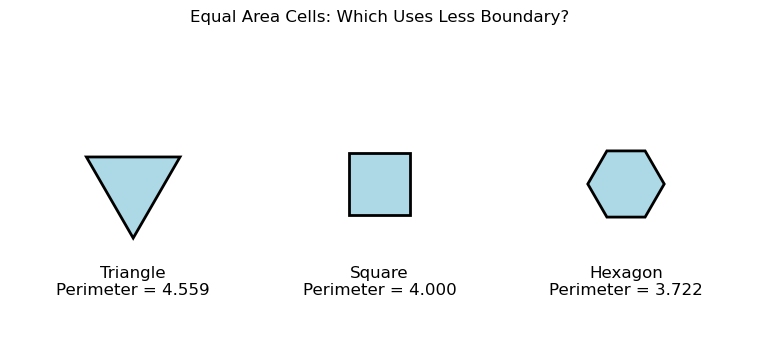

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

# ----------------------------------------------------
# Compare Triangle, Square, Hexagon
# All have the SAME AREA (=1)
# ----------------------------------------------------

AREA = 1.0

shapes = [
    ("Triangle", 3),
    ("Square", 4),
    ("Hexagon", 6)
]

fig, ax = plt.subplots(figsize=(12, 4))

x_positions = [0, 4, 8]

for x, (name, n) in zip(x_positions, shapes):

    # Side length for equal area
    s = np.sqrt((4 * AREA * np.tan(np.pi / n)) / n)

    # Circumradius
    R = s / (2 * np.sin(np.pi / n))

    # Perimeter
    perimeter = n * s

    polygon = RegularPolygon(
        (x, 0),
        numVertices=n,
        radius=R,
        orientation=np.pi / n,
        edgecolor='black',
        facecolor='lightblue',
        linewidth=2
    )

    ax.add_patch(polygon)

    ax.text(
        x,
        -1.8,
        f"{name}\nPerimeter = {perimeter:.3f}",
        ha='center',
        fontsize=12
    )

ax.set_xlim(-2, 10)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.axis('off')

plt.title("Equal Area Cells: Which Uses Less Boundary?")
plt.show()

# Rectangle inside ellipse ....

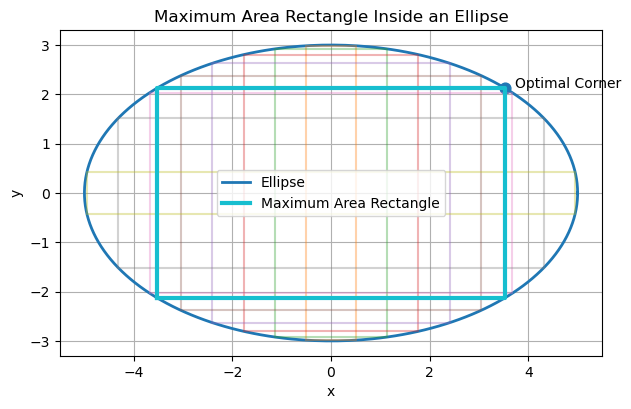

Maximum area = 29.999999999999996


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Ellipse parameters
# ---------------------------------------
a = 5      # semi-major axis
b = 3      # semi-minor axis

theta = np.linspace(0, 2*np.pi, 400)
xe = a*np.cos(theta)
ye = b*np.sin(theta)

plt.figure(figsize=(7,7))

# Draw ellipse
plt.plot(xe, ye, linewidth=2, label="Ellipse")

# ---------------------------------------
# Draw several rectangles
# ---------------------------------------

x_values = np.linspace(0.5, a*0.99, 8)

best_area = 0

for x in x_values:

    y = b*np.sqrt(1 - x**2/a**2)

    area = 4*x*y

    if area > best_area:
        best_area = area

    xs = [-x, x, x, -x, -x]
    ys = [-y, -y, y, y, -y]

    plt.plot(xs, ys, alpha=0.35)

# ---------------------------------------
# Optimal rectangle
# ---------------------------------------

xopt = a/np.sqrt(2)
yopt = b/np.sqrt(2)

xs = [-xopt, xopt, xopt, -xopt, -xopt]
ys = [-yopt, -yopt, yopt, yopt, -yopt]

plt.plot(xs, ys,
         linewidth=3,
         label="Maximum Area Rectangle")

plt.scatter([xopt],[yopt],s=60)
plt.text(xopt+0.2,yopt,
         "Optimal Corner")

plt.gca().set_aspect('equal')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Maximum Area Rectangle Inside an Ellipse")
plt.grid(True)
plt.legend()

plt.show()

print("Maximum area =",4*xopt*yopt)

# Soda can 

Optimal radius  = 3.833 cm
Optimal height  = 7.692 cm
h/(2r) = 1.0035


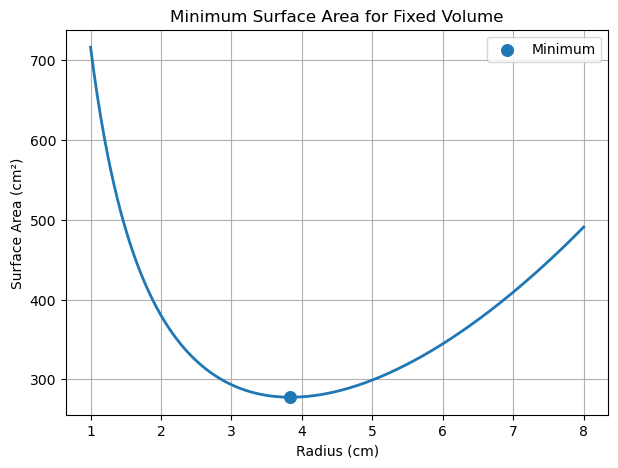

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Fixed volume
# ---------------------------------

V = 355          # cm^3 (roughly a soda can)

# Radius values
r = np.linspace(1, 8, 300)

# Corresponding height
h = V / (np.pi * r**2)

# Surface area
S = 2*np.pi*r**2 + 2*np.pi*r*h

# Numerical optimum
idx = np.argmin(S)

r_opt = r[idx]
h_opt = h[idx]
S_opt = S[idx]

print(f"Optimal radius  = {r_opt:.3f} cm")
print(f"Optimal height  = {h_opt:.3f} cm")
print(f"h/(2r) = {h_opt/(2*r_opt):.4f}")

plt.figure(figsize=(7,5))

plt.plot(r, S, linewidth=2)

plt.scatter(r_opt, S_opt,
            s=70,
            label="Minimum")

plt.xlabel("Radius (cm)")
plt.ylabel("Surface Area (cm²)")
plt.title("Minimum Surface Area for Fixed Volume")
plt.grid(True)
plt.legend()

plt.show()

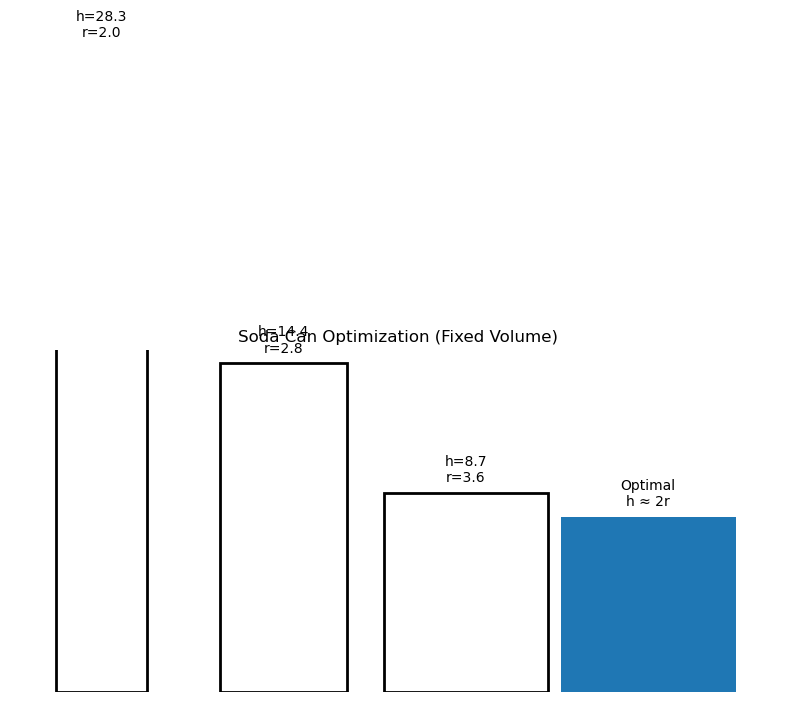

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Fixed volume
V = 355

# Different radii
radii = [2.0, 2.8, 3.6]

fig, ax = plt.subplots(figsize=(10,5))

xshift = 0

for r in radii:

    h = V/(np.pi*r*r)

    # Cylinder represented by a rectangle
    ax.add_patch(
        Rectangle(
            (xshift-r,0),
            2*r,
            h,
            fill=False,
            linewidth=2
        )
    )

    ax.text(xshift,
            h+0.5,
            f"h={h:.1f}\nr={r:.1f}",
            ha='center')

    xshift += 8

# Optimal can
r = (V/(2*np.pi))**(1/3)
h = 2*r

ax.add_patch(
    Rectangle(
        (xshift-r,0),
        2*r,
        h,
        linewidth=3
    )
)

ax.text(xshift,
        h+0.5,
        "Optimal\nh ≈ 2r",
        ha='center')

ax.set_xlim(-4, xshift+6)
ax.set_ylim(0,15)
ax.set_aspect('equal')
ax.set_title("Soda Can Optimization (Fixed Volume)")
ax.axis('off')

plt.show()

# Horons problem ...

Optimal touching point = 5.317725752508361


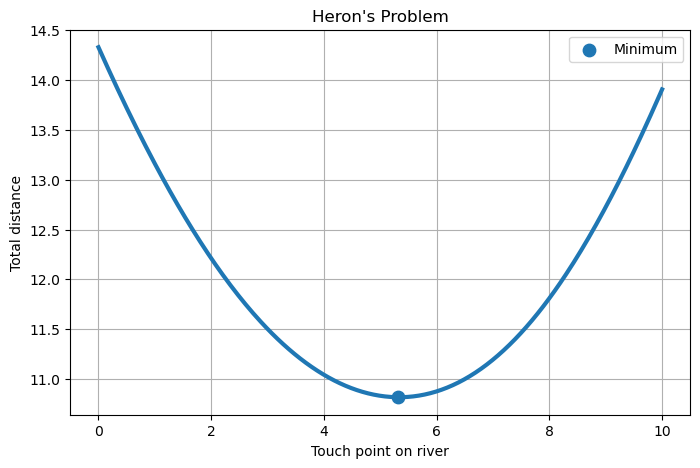

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Points
# -----------------------------------

A = np.array([2, 5])
B = np.array([8, -4])

# River is y = 0

x = np.linspace(0, 10, 300)

total_distance = []

for xi in x:

    P = np.array([xi, 0])

    d = np.linalg.norm(A-P) + np.linalg.norm(B-P)

    total_distance.append(d)

total_distance = np.array(total_distance)

idx = np.argmin(total_distance)

xopt = x[idx]

print("Optimal touching point =", xopt)

# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(8,5))

plt.plot(x, total_distance, linewidth=3)

plt.scatter(xopt,
            total_distance[idx],
            s=80,
            label="Minimum")

plt.xlabel("Touch point on river")
plt.ylabel("Total distance")
plt.title("Heron's Problem")
plt.grid(True)
plt.legend()

plt.show()

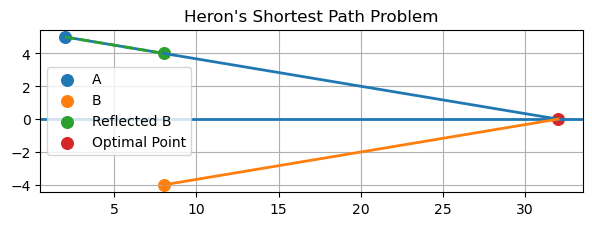

In [9]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([2,5])
B = np.array([8,-4])

# Reflection
B_ref = np.array([8,4])

# Line from A to reflected B
m = (B_ref[1]-A[1])/(B_ref[0]-A[0])

x_touch = A[0] + (0-A[1])/m

P = np.array([x_touch,0])

plt.figure(figsize=(7,6))

# River
plt.axhline(0,linewidth=2)

# Original path
plt.plot([A[0],P[0]],[A[1],P[1]],linewidth=2)
plt.plot([P[0],B[0]],[P[1],B[1]],linewidth=2)

# Reflected path
plt.plot([A[0],B_ref[0]],[A[1],B_ref[1]],
         '--',
         linewidth=2)

plt.scatter(*A,s=70,label="A")
plt.scatter(*B,s=70,label="B")
plt.scatter(*B_ref,s=70,label="Reflected B")
plt.scatter(*P,s=70,label="Optimal Point")

plt.gca().set_aspect("equal")
plt.grid(True)
plt.legend()

plt.title("Heron's Shortest Path Problem")

plt.show()

# Snell's law demonstartion 

Optimal entry x = 7.593984962406014
Minimum time = 3.7431246065883936


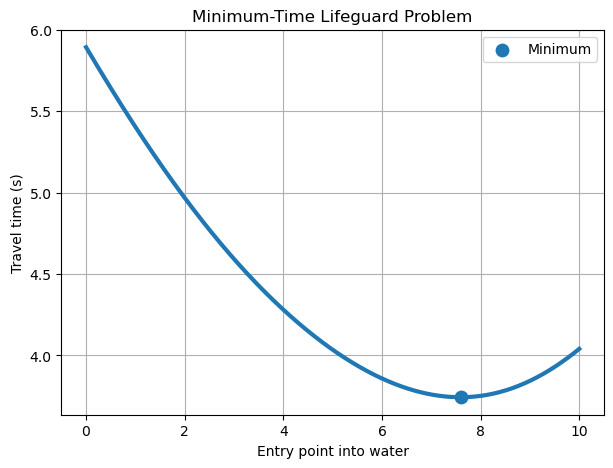

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Geometry
# ---------------------------------

A = np.array([2, 4])      # Lifeguard (sand)
B = np.array([9, -5])     # Victim (water)

# Interface is y = 0

v_land = 6.0      # m/s
v_water = 2.0     # m/s

x = np.linspace(0, 10, 400)

times = []

for xi in x:

    P = np.array([xi,0])

    d_land = np.linalg.norm(A-P)
    d_water = np.linalg.norm(B-P)

    t = d_land/v_land + d_water/v_water

    times.append(t)

times = np.array(times)

idx = np.argmin(times)

print("Optimal entry x =",x[idx])
print("Minimum time =",times[idx])

plt.figure(figsize=(7,5))

plt.plot(x,times,lw=3)

plt.scatter(x[idx],
            times[idx],
            s=80,
            label="Minimum")

plt.xlabel("Entry point into water")
plt.ylabel("Travel time (s)")
plt.title("Minimum-Time Lifeguard Problem")
plt.grid(True)
plt.legend()

plt.show()

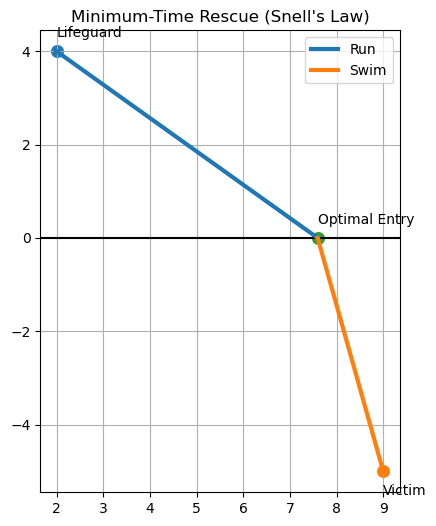

In [11]:
import numpy as np
import matplotlib.pyplot as plt

A=np.array([2,4])
B=np.array([9,-5])

v_land=6
v_water=2

x=np.linspace(0,10,500)

times=[]

for xi in x:

    P=np.array([xi,0])

    t=np.linalg.norm(A-P)/v_land \
      +np.linalg.norm(B-P)/v_water

    times.append(t)

times=np.array(times)

P=np.array([x[np.argmin(times)],0])

plt.figure(figsize=(8,6))

# shoreline
plt.axhline(0,color='k')

# optimal path
plt.plot([A[0],P[0]],
         [A[1],P[1]],
         lw=3,
         label="Run")

plt.plot([P[0],B[0]],
         [P[1],B[1]],
         lw=3,
         label="Swim")

plt.scatter(*A,s=70)
plt.scatter(*B,s=70)
plt.scatter(*P,s=70)

plt.text(A[0],A[1]+0.3,"Lifeguard")
plt.text(B[0],B[1]-0.5,"Victim")
plt.text(P[0],0.3,"Optimal Entry")

plt.gca().set_aspect('equal')

plt.grid(True)
plt.legend()

plt.title("Minimum-Time Rescue (Snell's Law)")

plt.show()

# Minimum Spanning Tree (MST)

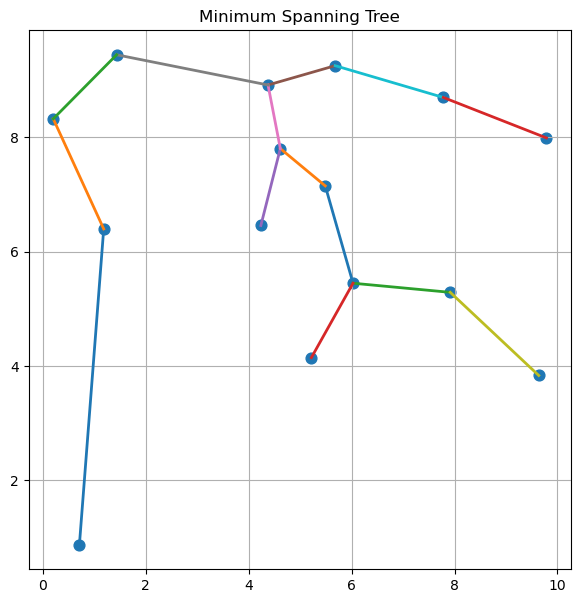

Total cable length = 29.10685740639097


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

# -----------------------------
# Random cities
# -----------------------------

np.random.seed(0)

points = np.random.rand(15,2)*10

# Distance matrix
D = distance_matrix(points, points)

# Minimum spanning tree
mst = minimum_spanning_tree(D).toarray()

plt.figure(figsize=(7,7))

# Plot cities
plt.scatter(points[:,0], points[:,1], s=60)

# Draw MST edges
for i in range(len(points)):
    for j in range(len(points)):
        if mst[i,j] > 0:
            plt.plot([points[i,0], points[j,0]],
                     [points[i,1], points[j,1]],
                     linewidth=2)

plt.title("Minimum Spanning Tree")

plt.grid(True)

plt.show()

print("Total cable length =", mst.sum())

# Annealing 

Best x = -3.0008110102550165
Best value = -116.99997368409304


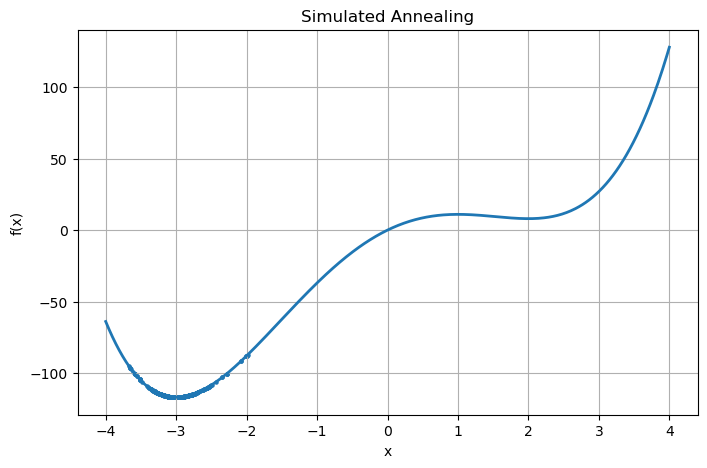

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------
# Objective function
# ------------------------------------

def f(x):
    return x**4 - 14*x**2 + 24*x

# ------------------------------------

T = 10.0
cooling = 0.995

x = np.random.uniform(-4,4)

history = []

for _ in range(5000):

    x_new = x + np.random.normal(scale=0.5)

    delta = f(x_new)-f(x)

    if delta < 0:
        x = x_new
    else:
        if np.random.rand() < np.exp(-delta/T):
            x = x_new

    history.append(x)

    T *= cooling

print("Best x =",x)
print("Best value =",f(x))

# Plot function
xx = np.linspace(-4,4,500)

plt.figure(figsize=(8,5))

plt.plot(xx,f(xx),linewidth=2)

plt.scatter(history,
            [f(i) for i in history],
            s=5)

plt.xlabel("x")

plt.ylabel("f(x)")

plt.title("Simulated Annealing")

plt.grid(True)

plt.show()

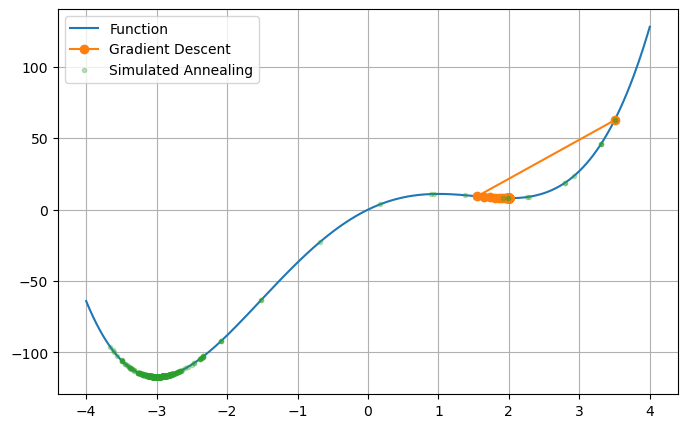

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**4 - 14*x**2 + 24*x

def grad(x):
    return 4*x**3 - 28*x + 24

# Gradient Descent
x = 3.5
lr = 0.02

gd = []

for _ in range(80):
    gd.append(x)
    x -= lr*grad(x)

# Simulated Annealing
T = 10

x = 3.5

sa = []

for _ in range(2000):

    sa.append(x)

    x_new = x + np.random.normal(scale=0.5)

    d = f(x_new)-f(x)

    if d < 0 or np.random.rand() < np.exp(-d/T):
        x = x_new

    T *= 0.995

xx = np.linspace(-4,4,500)

plt.figure(figsize=(8,5))

plt.plot(xx,f(xx),label="Function")

plt.plot(gd,[f(i) for i in gd],
         'o-',
         label="Gradient Descent")

plt.plot(sa,[f(i) for i in sa],
         '.',
         alpha=0.3,
         label="Simulated Annealing")

plt.legend()

plt.grid(True)

plt.show()

# Convergence of algorithms ....

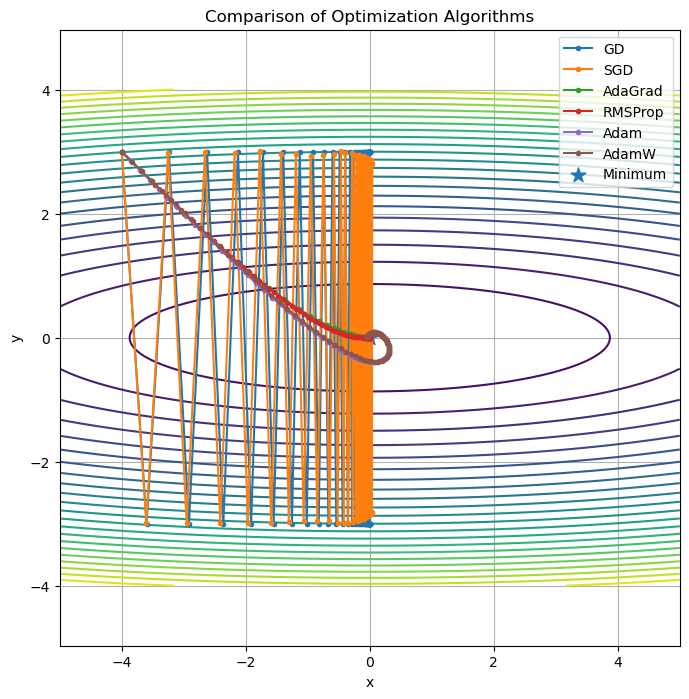

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Objective function
# =====================================================

def f(x, y):
    return x**2 + 20*y**2

def grad(x, y):
    return np.array([2*x, 40*y])


#def f(x, y):
#    return (1 - x)**2 + 100*(y - x**2)**2

#def grad(x, y):
#    dx = -2*(1-x) - 400*x*(y - x**2)
#    dy = 200*(y - x**2)
#    return np.array([dx, dy])

start = np.array([-1.5, 1.5])

# =====================================================
# Optimizers
# =====================================================

def gradient_descent(start, lr=0.05, steps=80):

    p = np.array(start, dtype=float)
    traj = [p.copy()]

    for _ in range(steps):
        g = grad(*p)
        p = p - lr*g
        traj.append(p.copy())

    return np.array(traj)


def sgd(start, lr=0.05, noise=0.3, steps=80):

    p = np.array(start, dtype=float)
    traj = [p.copy()]

    for _ in range(steps):

        g = grad(*p)

        g += noise*np.random.randn(2)

        p = p - lr*g

        traj.append(p.copy())

    return np.array(traj)


def adagrad(start, lr=1.0, eps=1e-8, steps=80):

    p = np.array(start, dtype=float)

    G = np.zeros(2)

    traj = [p.copy()]

    for _ in range(steps):

        g = grad(*p)

        G += g*g

        p -= lr*g/(np.sqrt(G)+eps)

        traj.append(p.copy())

    return np.array(traj)


def rmsprop(start, lr=0.1, beta=0.9, eps=1e-8, steps=80):

    p = np.array(start, dtype=float)

    s = np.zeros(2)

    traj = [p.copy()]

    for _ in range(steps):

        g = grad(*p)

        s = beta*s + (1-beta)*g*g

        p -= lr*g/(np.sqrt(s)+eps)

        traj.append(p.copy())

    return np.array(traj)


def adam(start,
         lr=0.15,
         beta1=0.9,
         beta2=0.999,
         eps=1e-8,
         steps=80):

    p = np.array(start, dtype=float)

    m = np.zeros(2)
    v = np.zeros(2)

    traj = [p.copy()]

    for t in range(1, steps+1):

        g = grad(*p)

        m = beta1*m + (1-beta1)*g

        v = beta2*v + (1-beta2)*g*g

        mhat = m/(1-beta1**t)
        vhat = v/(1-beta2**t)

        p -= lr*mhat/(np.sqrt(vhat)+eps)

        traj.append(p.copy())

    return np.array(traj)

def adamw(start,
          lr=0.15,
          weight_decay=0.02,
          beta1=0.9,
          beta2=0.999,
          eps=1e-8,
          steps=80):

    p = np.array(start, dtype=float)

    m = np.zeros(2)
    v = np.zeros(2)

    traj = [p.copy()]

    for t in range(1, steps + 1):

        g = grad(*p)

        # Adam moments
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g * g)

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        # Adam update
        p -= lr * m_hat / (np.sqrt(v_hat) + eps)

        # Decoupled weight decay
        p -= lr * weight_decay * p

        traj.append(p.copy())

    return np.array(traj)

# =====================================================
# Generate trajectories
# =====================================================

start = [-4, 3]
#start = np.array([-1.5, 1.5])
paths = {
    "GD": gradient_descent(start),
    "SGD": sgd(start),
    "AdaGrad": adagrad(start),
    "RMSProp": rmsprop(start),
    "Adam": adam(start),
    "AdamW": adamw(start)
}

# =====================================================
# Contour plot
# =====================================================

x = np.linspace(-5,5,300)
y = np.linspace(-4,4,300)

#x = np.linspace(-2, 2, 400)
#y = np.linspace(-1, 3, 400)

X,Y = np.meshgrid(x,y)

Z = f(X,Y)

plt.figure(figsize=(8,8))

plt.contour(X,Y,Z,
            levels=25)

for name,path in paths.items():

    plt.plot(path[:,0],
             path[:,1],
             marker='o',
             markersize=3,
             label=name)

plt.scatter(0,0,
            s=120,
            marker='*',
            label="Minimum")

plt.legend()

plt.xlabel("x")
plt.ylabel("y")

plt.title("Comparison of Optimization Algorithms")

plt.axis("equal")

plt.grid(True)

plt.show()

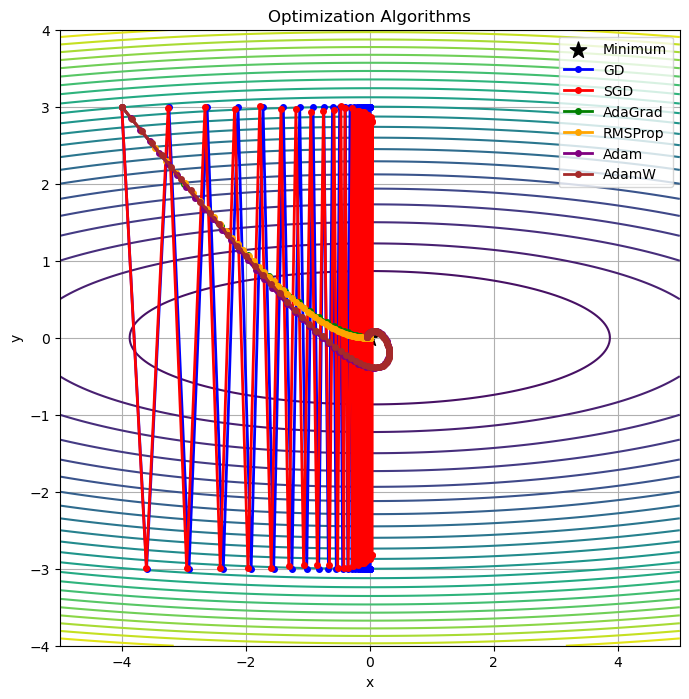

In [31]:
from matplotlib.animation import FuncAnimation, PillowWriter

# -------------------------------------------------
# Contour plot
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(8,8))

ax.contour(X, Y, Z, levels=25)

ax.scatter(0, 0,
           s=150,
           marker="*",
           color="black",
           label="Minimum")

# Create one line for each optimizer
lines = {}
colors = ["blue","red","green","orange","purple","brown"]

for (name, path), color in zip(paths.items(), colors):
    line, = ax.plot([], [],
                    '-o',
                    markersize=4,
                    linewidth=2,
                    color=color,
                    label=name)
    lines[name] = line

ax.set_xlim(-5,5)
ax.set_ylim(-4,4)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_title("Optimization Algorithms")

ax.grid(True)
ax.legend()

# -------------------------------------------------
# Animation
# -------------------------------------------------

max_steps = max(len(p) for p in paths.values())

def update(frame):

    for name, path in paths.items():

        if frame < len(path):

            lines[name].set_data(path[:frame+1,0],
                                 path[:frame+1,1])

        else:

            lines[name].set_data(path[:,0],
                                 path[:,1])

    return list(lines.values())

ani = FuncAnimation(fig,
                    update,
                    frames=max_steps,
                    interval=120,
                    blit=True)

# -------------------------------------------------
# Save GIF
# -------------------------------------------------

ani.save("optimizer_comparison.gif",
         writer=PillowWriter(fps=10))

plt.show()